Module 5: Performance Trend Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel("Supportlytics_Processed_Data.xlsx")
df.head()

,Ticket_ID,Created_Date,Resolution_Date,Status,Priority,Ticket_Type,Category,Country,Cluster_ID,Cluster_Name,...,Customer_Satisfaction,Escalation_Level,Region,Device_Type,Operating_System,Resolution_Notes,Resolution_Duration,Priority_score,Cluster,Queue
0,TKT000001,2025-04-14 22:00:00,2025-04-17 22:00:00,Open,Medium,Request,Network,USA,1,Network Issues,...,3,L2,North America,Mobile,RHEL,Resolved after troubleshooting network.,3,2,Security,Security Queue
1,TKT000002,2026-03-30 02:00:00,2026-03-30 02:00:00,Resolved,Low,Problem,Software,UAE,2,Software Issues,...,2,L3,North America,Mobile,Ubuntu,Resolved after troubleshooting software.,0,1,Security,Security Queue
2,TKT000003,2025-06-13 21:00:00,2025-06-15 21:00:00,Closed,Critical,Request,Software,USA,2,Software Issues,...,5,L3,Europe,Mobile,Ubuntu,Resolved after troubleshooting software.,2,4,Security,Security Queue
3,TKT000004,2025-03-22 01:00:00,2025-03-24 01:00:00,Resolved,High,Incident,Email,India,7,Email Issues,...,2,L3,Europe,Laptop,Windows 11,Resolved after troubleshooting email.,2,3,Applications,Applications Queue
4,TKT000005,2025-01-14 11:00:00,2025-01-18 11:00:00,Resolved,High,Request,Access Management,Canada,8,Access Management Issues,...,4,L1,North America,Server,RHEL,Resolved after troubleshooting access management.,4,3,Applications,Applications Queue


average resolution time by priority

In [2]:
priority_time = df.groupby("Priority")["Resolution_Duration"].mean()
print(priority_time)

Priority
Critical    1.002220
High        1.976105
Low         6.035462
Medium      3.514523
Name: Resolution_Duration, dtype: float64


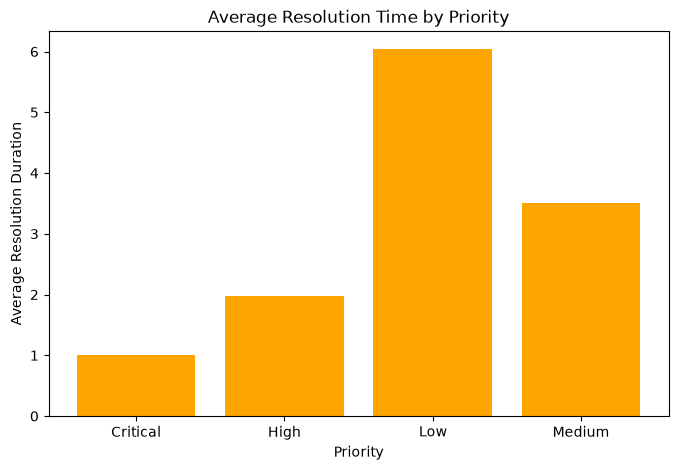

In [3]:
plt.figure(figsize=(8,5))
plt.bar(
    priority_time.index,
    priority_time.values,
    color="orange"
)
plt.title("Average Resolution Time by Priority")
plt.xlabel("Priority")
plt.ylabel("Average Resolution Duration")
plt.show()

In [4]:
ticket_time = df.groupby("Ticket_Type")["Resolution_Duration"].mean()
print(ticket_time)

Ticket_Type
Incident    3.118332
Problem     3.163299
Request     3.112430
Name: Resolution_Duration, dtype: float64


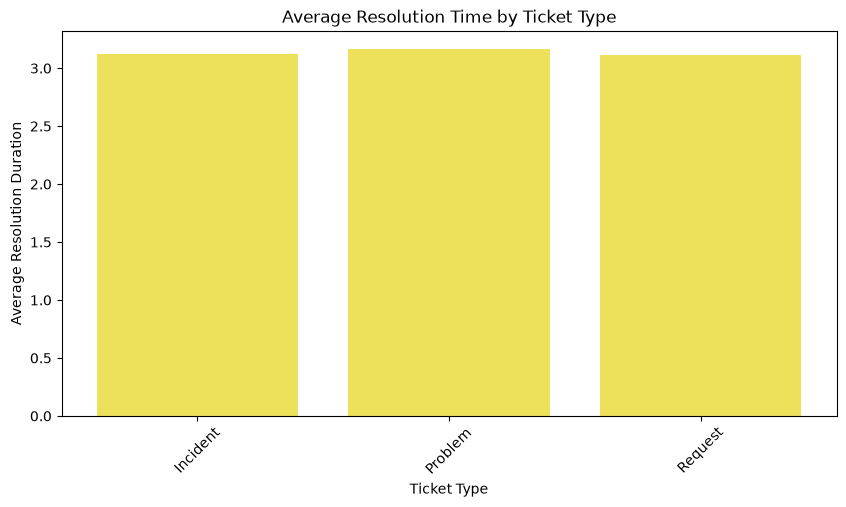

In [5]:
plt.figure(figsize=(10,5))
plt.bar(
    ticket_time.index,
    ticket_time.values,
    color="#ede15b"
)
plt.title("Average Resolution Time by Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Average Resolution Duration")
plt.xticks(rotation=45)
plt.show()

fastest Countries

In [6]:
country_time = (
    df.groupby("Country")["Resolution_Duration"]
      .mean()
      .sort_values()
)
print(country_time)

Country
Canada       3.048857
India        3.064309
UAE          3.121990
USA          3.133896
Australia    3.139401
Singapore    3.145455
UK           3.188170
Germany      3.210211
Name: Resolution_Duration, dtype: float64


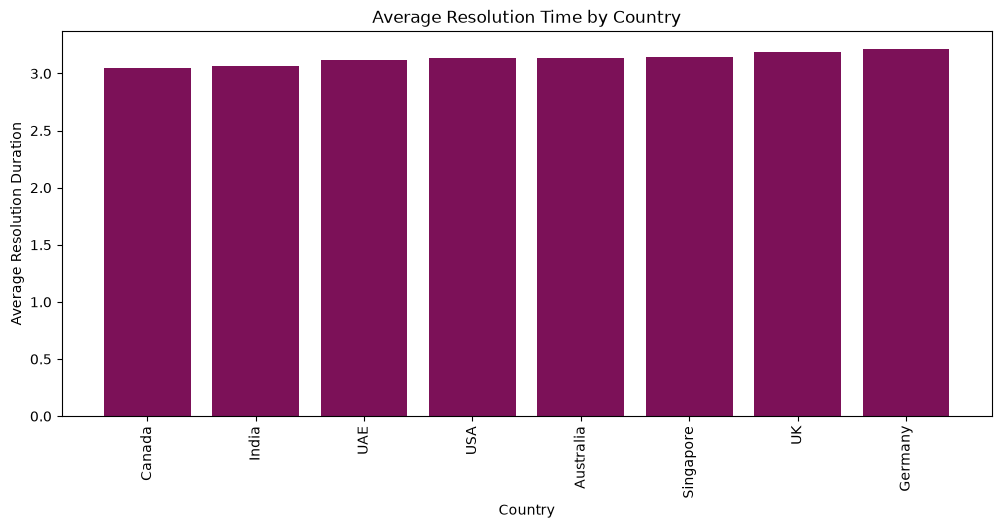

In [7]:
plt.figure(figsize=(12,5))

plt.bar(
    country_time.index,
    country_time.values,
    color="#7c1158"
)
plt.title("Average Resolution Time by Country")
plt.xlabel("Country")
plt.ylabel("Average Resolution Duration")

plt.xticks(rotation=90)

plt.show()

Fastest Teams 

In [8]:
team_time = (
    df.groupby("Team")["Resolution_Duration"]
      .mean()
      .sort_values()
)
print(team_time)

Team
Applications      3.083966
Security          3.142914
Infrastructure    3.144848
Service Desk      3.152613
Name: Resolution_Duration, dtype: float64


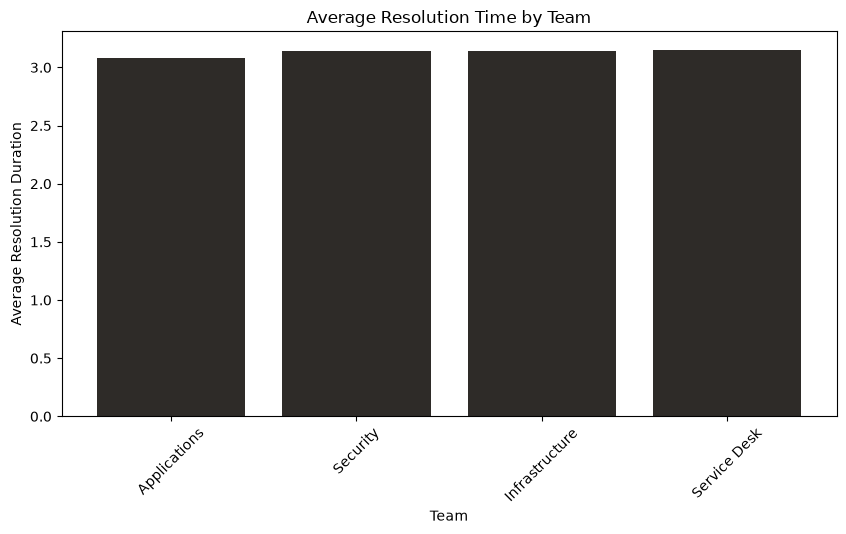

In [9]:
plt.figure(figsize=(10,5))

plt.bar(
    team_time.index,
    team_time.values,
    color="#2e2b28"
)
plt.title("Average Resolution Time by Team")
plt.xlabel("Team")
plt.ylabel("Average Resolution Duration")

plt.xticks(rotation=45)

plt.show()

High-Priority Unresolved Issues

In [10]:
high_priority_unresolved = df[
    (df["Priority"] == "High") &
    (df["Status"] != "Resolved")
]
print(high_priority_unresolved)

       Ticket_ID        Created_Date     Resolution_Date       Status  \
7      TKT000008 2025-01-29 19:00:00 2025-01-30 19:00:00         Open   
9      TKT000010 2025-10-13 00:00:00 2025-10-15 00:00:00       Closed   
17     TKT000018 2025-02-18 23:00:00 2025-02-20 23:00:00  In Progress   
21     TKT000022 2025-06-02 01:00:00 2025-06-05 01:00:00  In Progress   
28     TKT000029 2025-01-26 08:00:00 2025-01-29 08:00:00       Closed   
...          ...                 ...                 ...          ...   
19984  TKT019985 2026-03-19 01:00:00 2026-03-22 01:00:00       Closed   
19990  TKT019991 2025-01-03 03:00:00 2025-01-07 03:00:00       Closed   
19991  TKT019992 2026-06-18 02:00:00 2026-06-19 02:00:00       Closed   
19996  TKT019997 2025-05-18 04:00:00 2025-05-20 04:00:00         Open   
19998  TKT019999 2026-02-04 08:00:00 2026-02-06 08:00:00  In Progress   

      Priority Ticket_Type           Category    Country  Cluster_ID  \
7         High     Problem              Email      

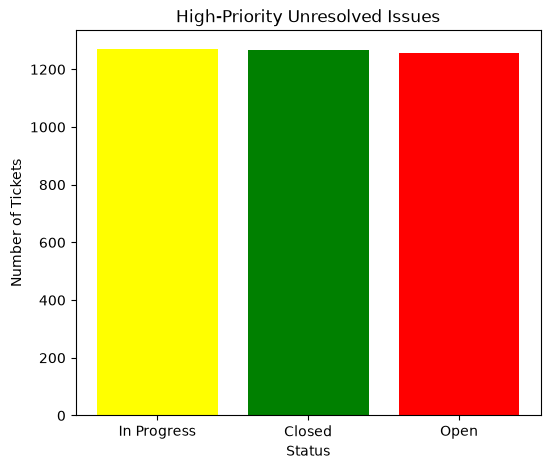

In [11]:
status_count = high_priority_unresolved["Status"].value_counts()

colors = []

for status in status_count.index:
    if status == "Open":
        colors.append("red")
    elif status == "In Progress":
        colors.append("yellow")
    elif status == "Closed":
        colors.append("green")
    else:
        colors.append("gray")
plt.figure(figsize=(6,5))

plt.bar(
    status_count.index,
    status_count.values,
    color=colors
)
plt.title("High-Priority Unresolved Issues")
plt.xlabel("Status")
plt.ylabel("Number of Tickets")
plt.show()

In [19]:
pip install plotly

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.9 MB 1.5 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/9.9 MB 1.8 MB/s eta 0:00:05
   ------- -------------------------------- 1.8/9.9 MB 2.1 MB/s eta 0:00:04
   ---------- ----------------------------- 2.6/9.9 MB 2.4 MB/s eta 0:00:04
   -------------- ------------------------- 3.7/9.9 MB 2.8 MB/s eta 0:00:03
   ----------------- ---------------------- 4.5/9.9 MB 3.0 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.9 MB 3.1 MB/s eta 0:00:02
   ------------------------ --------------- 6.0/9.9 MB 3.1 MB/s eta 0:00:02
   --------------------------- ------------ 6.8/9.9 MB 3.2 MB/s eta 0:00:01
   ----------------------------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Module 6 


In [23]:
import pandas as pd
import plotly.express as px
region_counts = df["Region"].value_counts().reset_index()
region_counts.columns = ["Region", "Tickets"]
region_coords = {
    "Asia": (34.0, 100.0),
    "Europe": (54.0, 15.0),
    "North America": (45.0, -100.0),
    "Middle East": (26.0, 45.0),
    "Oceania": (-25.0, 135.0)
}
region_counts["Latitude"] = region_counts["Region"].map(lambda x: region_coords[x][0])
region_counts["Longitude"] = region_counts["Region"].map(lambda x: region_coords[x][1])
fig = px.scatter_geo(
    region_counts,
    lat="Latitude",
    lon="Longitude",
    size="Tickets",
    color="Tickets",
    hover_name="Region",
    title="Geographical Distribution of Support Tickets",
    projection="natural earth"
)

fig.show()

Issue Categories by Region


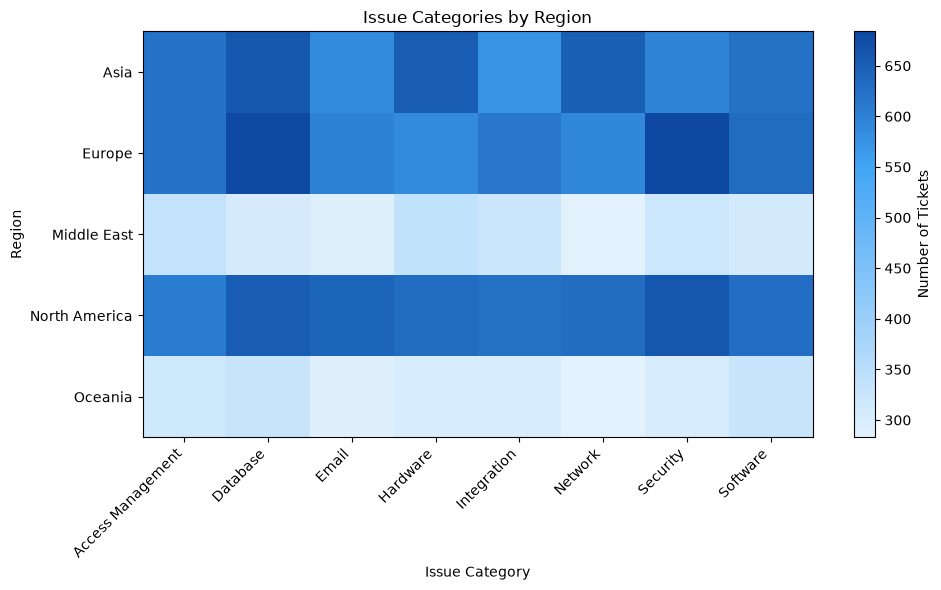

In [22]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
category_region = pd.crosstab(df["Region"], df["Category"])
blue_shades = LinearSegmentedColormap.from_list(
    "blue_shades",
    ["#E3F2FD", "#90CAF9", "#42A5F5", "#0D47A1"]
)
plt.figure(figsize=(10,6))
plt.imshow(
    category_region,
    cmap=blue_shades,
    aspect="auto"
)
plt.colorbar(label="Number of Tickets")
plt.xticks(
    range(len(category_region.columns)),
    category_region.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(category_region.index)),
    category_region.index
)
plt.xlabel("Issue Category")
plt.ylabel("Region")
plt.title("Issue Categories by Region")
plt.tight_layout()
plt.show()

Cluster Size vs Performance Score

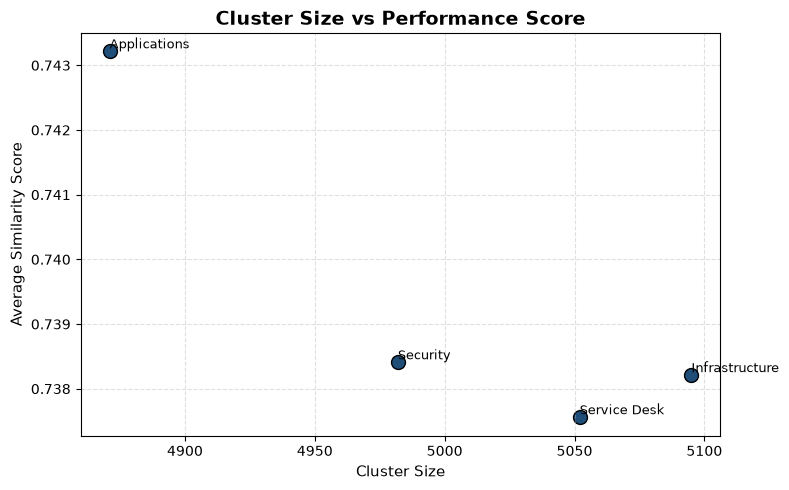

In [ ]:
import matplotlib.pyplot as plt

cluster_summary = df.groupby("Cluster").agg(
    Cluster_Size=("Cluster", "count"),
    Performance_Score=("Similarity_Score", "mean")
).reset_index()

plt.figure(figsize=(8,5))

plt.scatter(
    cluster_summary["Cluster_Size"],
    cluster_summary["Performance_Score"],
    color="#1F4E79",      
    s=100,
    edgecolor="black",
    linewidth=1
)

for i in range(len(cluster_summary)):
    plt.text(
        cluster_summary["Cluster_Size"][i],
        cluster_summary["Performance_Score"][i],
        cluster_summary["Cluster"][i],
        fontsize=9,
        ha="left",
        va="bottom"
    )

plt.xlabel("Cluster Size", fontsize=11)
plt.ylabel("Average Similarity Score", fontsize=11)
plt.title("Cluster Size vs Performance Score",
          fontsize=14,
          fontweight="bold")

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Average Resolution Time by Region


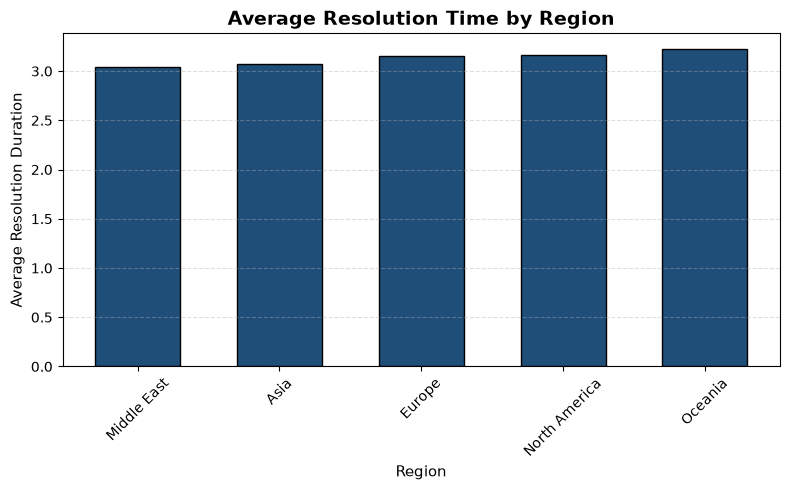

In [15]:
import matplotlib.pyplot as plt

# Calculate average resolution time by region
region_resolution = df.groupby("Region")["Resolution_Duration"].mean().sort_values()

plt.figure(figsize=(8,5))

plt.bar(
    region_resolution.index,
    region_resolution.values,
    color="#1F4E79",      # Professional Navy Blue
    edgecolor="black",
    width=0.6
)

plt.xlabel("Region", fontsize=11)
plt.ylabel("Average Resolution Duration", fontsize=11)
plt.title("Average Resolution Time by Region",
          fontsize=14,
          fontweight="bold")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Average Customer Satisfaction by Region

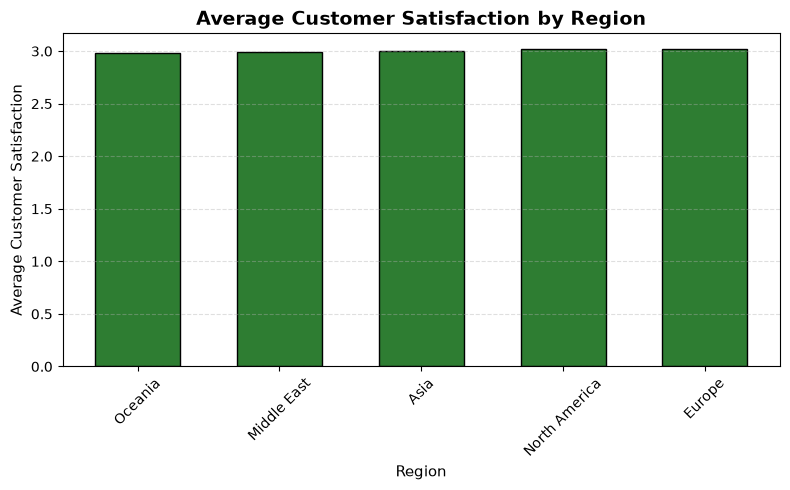

In [ ]:
import matplotlib.pyplot as plt

region_satisfaction = df.groupby("Region")["Customer_Satisfaction"].mean().sort_values()

plt.figure(figsize=(8,5))

plt.bar(
    region_satisfaction.index,
    region_satisfaction.values,
    color="#2E7D32",      
    edgecolor="black",
    width=0.6
)

plt.xlabel("Region", fontsize=11)
plt.ylabel("Average Customer Satisfaction", fontsize=11)
plt.title("Average Customer Satisfaction by Region",
          fontsize=14,
          fontweight="bold")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [17]:

performance_summary = pd.DataFrame({
    "Metric": [
        "Total Tickets",
        "Average Resolution Duration",
        "Average Similarity Score",
        "Average Customer Satisfaction",
        "Resolved Tickets",
        "Unresolved Tickets"
    ],
    "Value": [
        len(df),
        round(df["Resolution_Duration"].mean(), 2),
        round(df["Similarity_Score"].mean(), 2),
        round(df["Customer_Satisfaction"].mean(), 2),
        (df["Status"] == "Resolved").sum(),
        (df["Status"] != "Resolved").sum()
    ]
})

print(performance_summary)

                          Metric     Value
0                  Total Tickets  20000.00
1    Average Resolution Duration      3.13
2       Average Similarity Score      0.74
3  Average Customer Satisfaction      3.01
4               Resolved Tickets   4967.00
5             Unresolved Tickets  15033.00
